In [1]:
# Data I'm usimg:
# City of Chicago's Public Crime Data: https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data
# There are about 8.34 million records from 2001 to last week. The report is updated every day. 

# Variables: ID, Case Number, Date, Block, IUCR (The Illinois Uniform Crime Reporting code), Primary Type, Description, Location Description, Arrest
# Variables Cont: Domestic, Beat, District, Ward, Community Area, FBI Code, X Coordinate, Y Coordinate, Year, Updated On, Latitude, Longitude, Location
# Types: Number, Text, Floating Timestamp, Checkbox

# Data Preparation: Removed irrelevant columns and columns with missing or null values.
# Data Prep Part 2: Converted Date to datetime for later analysis and saved time features for trend analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("C:/Users/Ayesh/Downloads/chicago_crime.csv")

df.shape
df.head()
df.columns
df.info()
df.describe(include='all')

df.isnull().sum()

df = df[['Date', 'Primary Type', 'Location Description', 'Arrest', 'Community Area', 'Latitude', 'Longitude']]

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Primary Type', 'Date', 'Community Area', 'Latitude', 'Longitude'])

df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335148 entries, 0 to 8335147
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Case Number           object 
 2   Date                  object 
 3   Block                 object 
 4   IUCR                  object 
 5   Primary Type          object 
 6   Description           object 
 7   Location Description  object 
 8   Arrest                bool   
 9   Domestic              bool   
 10  Beat                  int64  
 11  District              float64
 12  Ward                  float64
 13  Community Area        float64
 14  FBI Code              object 
 15  X Coordinate          float64
 16  Y Coordinate          float64
 17  Year                  int64  
 18  Updated On            object 
 19  Latitude              float64
 20  Longitude             float64
 21  Location              object 
dtypes: bool(2), float64(7), int64(3), object(1

C:\Users\Ayesh\AppData\Local\Temp\ipykernel_6484\1729047733.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="magma")


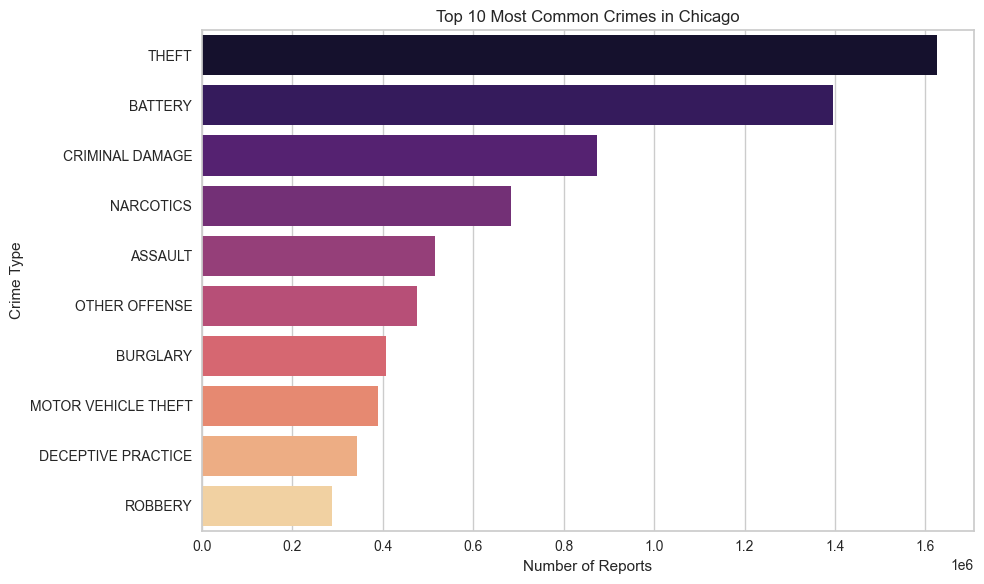

In [3]:
# Plot top 10 highest types of crime
df.head()
top_crimes = df['Primary Type'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="magma")
plt.title("Top 10 Most Common Crimes in Chicago")
plt.xlabel("Number of Reports")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()

top5 = ['Theft', 'Battery', 'Criminal Damage', 'Narcotics', 'Assault']
df = df[df['Primary Type'].isin(top5)]

# Results of plot: 
# The top 10 most common crime types are: Theft, Battery, Criminal Damage, Narcotics, Assault, Other Offense, Burglary, 
# Motor Vehicle Theft, Deceptive Practice, and Robbery. I'm only keeping the top 5

In [4]:
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month

# Define season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
df['Season'] = df['Month'].apply(get_season)

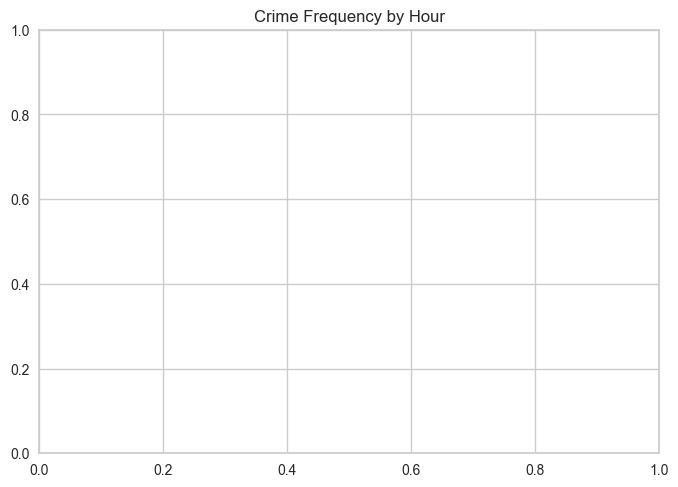

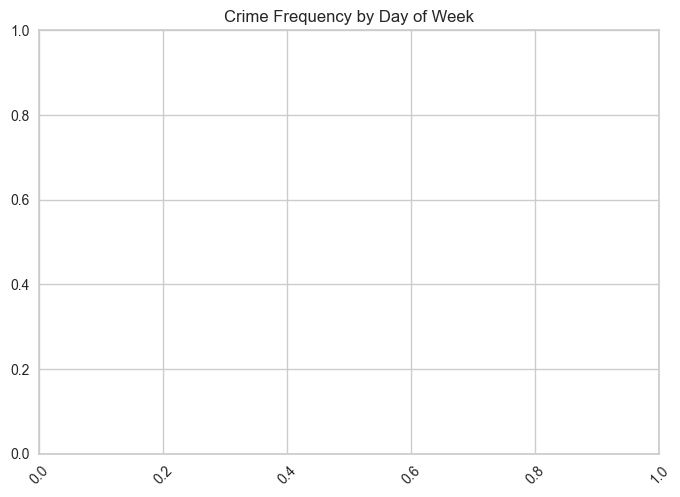

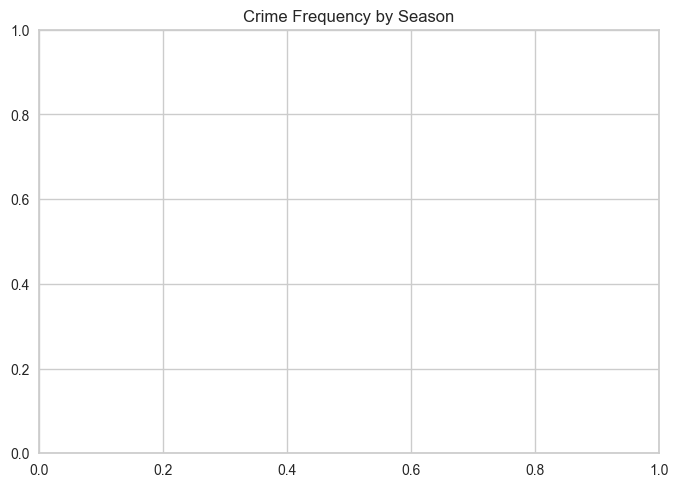

In [5]:
sns.countplot(data=df, x='Hour', palette='coolwarm')
plt.title("Crime Frequency by Hour")
plt.show()

sns.countplot(data=df, x='DayOfWeek', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='pastel')
plt.title("Crime Frequency by Day of Week")
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=df, x='Season', palette='Set2')
plt.title("Crime Frequency by Season")
plt.show()

In [6]:
df['Crime_Code'] = df['Primary Type'].replace({
    'Theft': 0,
    'Battery': 1,
    'Criminal Damage': 2,
    'Narcotics': 3,
    'Assault': 4
})

# Encode input features 
df['DayOfWeek_Code'] = df['DayOfWeek'].astype('category').cat.codes
df['Season_Code'] = df['Season'].astype('category').cat.codes

# Define X and y 
features = ['Hour', 'DayOfWeek_Code', 'Season_Code', 'Community Area', 'Latitude', 'Longitude']
X = df[features]
y = df['Crime_Code']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Decision Tree model
clf = DecisionTreeClassifier(max_depth=None, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
print(X_train.shape)
print(X_test.shape)

# Step 3: Grid search like in demo
start = time.time()

svc = SVC(random_state=2021)

param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100, 1000]},
    {'kernel': ['poly'], 'degree': [2, 3, 5], 'C': [0.1, 1, 10, 100, 1000]},
    {'kernel': ['rbf'], 'gamma': ['auto', 'scale'], 'C': [0.1, 1, 10, 100, 1000]},
    {'kernel': ['sigmoid'], 'gamma': ['auto', 'scale'], 'C': [0.1, 1, 10, 100, 1000]},
]

scores = ['precision', 'recall']

for score in scores:
    print(f'# Tuning hyper-parameters for {score}\n')

    CV_svc = GridSearchCV(
        estimator=svc,
        param_grid=param_grid,
        scoring=f'{score}_macro',
        cv=10,
        verbose=1,
        n_jobs=-1
    )
    CV_svc.fit(X_train, y_train.values.ravel())

    print("Best parameters set found on development set:\n")
    print(CV_svc.best_params_)
    print("\nGrid scores on development set:\n")
    means = CV_svc.cv_results_['mean_test_score']
    stds = CV_svc.cv_results_['std_test_score']

    for mean, std, params in zip(means, stds, CV_svc.cv_results_['params']):
        print(f"{mean:.3f} (+/-{std * 2:.03f}) for {params}")
    print()

    print("Detailed classification report:\n")
    y_true, y_pred = y_test, CV_svc.predict(X_test)
    print(classification_report(y_true, y_pred))
    print()

print("Total time:", round(time.time() - start, 2), "seconds")

# Fitting the best model and evaluate on test set like in demo
best_svc = CV_svc.best_estimator_
best_svc.fit(X_train, y_train.values.ravel())

y_test_pred = best_svc.predict(X_test)

# Step 5: Printing 
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# Plotting
ConfusionMatrixDisplay.from_estimator(best_svc, X_test, y_test)
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

pca = PCA(random_state=2021, n_components=None)
pca.fit(X_scaled_df)
X_pca = pca.transform(X_scaled_df)

exp_var_ratio = pca.explained_variance_ratio_

def explained_variance_ratio_plot(exp_var_ratio):
    x_axis = range(1, len(exp_var_ratio)+1)
    plt.bar(x_axis, exp_var_ratio, align='center', label='Individual EVR')
    plt.step(x_axis, np.cumsum(exp_var_ratio), where='mid', color='red', label='Cumulative EVR')
    plt.ylim(0, 1.1)
    plt.xticks(x_axis)
    plt.xlabel('Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.grid()
    plt.legend()
    plt.title("Explained Variance by Principal Component")
    plt.show()

explained_variance_ratio_plot(exp_var_ratio)

num_pc = 5
loadings = pca.components_
pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))]

loadings_df = pd.DataFrame(loadings, columns=features, index=pc_list)
sns.heatmap(loadings_df.T, annot=True, cmap='Spectral')
plt.title("PCA Component Loadings (Crime Features)")
plt.show()

In [ ]:
df_pc12 = scores_df[['PC1', 'PC2']]
state_st = StandardScaler().fit_transform(df_pc12)

scores = []
cluster_results = {}

kmeans = KMeans()

for n in range(2, 14):
    kmeans.set_params(n_clusters=n)
    labels = kmeans.fit_predict(state_st)
    cluster_results[n] = labels
    score = silhouette_score(state_st, labels)
    scores.append(score)

plt.figure(figsize=(12, 6))
plt.title("Silhouette Score for Crime Clusters (PC1 & PC2)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.plot(range(2, 14), scores, marker='s')
plt.grid()
plt.show()

In [ ]:
kmeans = KMeans()
elbow = KElbowVisualizer(kmeans, k=(2, 20))
elbow.fit(state_st)
elbow.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(state_st)

scores_df['cluster'] = labels + 1

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(state_st[:, 0], state_st[:, 1], c=labels, cmap="viridis", s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", s=200, alpha=0.8, label="Centroids")
plt.title("K-Means Clusters (Crime PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

In [ ]:
cluster_summary = scores_df.groupby('cluster')[['PC1', 'PC2']].mean()
print(cluster_summary)

In [ ]:
# Academic Integrity Statement: I did not use artificial intelligence to help me with this assignment, and I am aware that if I did, 
# I would have to provide the link to the transcript of the session. 
# Also I submitted a downloaded version of the code. 